# HAWC Catalog Examples

This notebook demonstrates how to use FeuPy utilities together with Gammapy to work with the 3HWC and 2HWC catalogs. It shows how to create flux-point tables, build `FluxPoints` objects, inspect catalog metadata, and visualize spectral energy distributions (SEDs).

In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst

import gammapy
from gammapy.catalog import SourceCatalog2HWC, SourceCatalog3HWC

import feupy
from feupy.catalogs.hawc import (
    create_flux_points_table_2hwc,
    create_flux_points_table_3hwc,
    get_flux_points_2hwc,
    get_flux_points_3hwc,
)

print("FeuPy version:", feupy.__version__)
print("Gammapy version:", gammapy.__version__)

## 3HWC catalog

Load the 3HWC catalog, select a source, create flux points, and inspect the corresponding table and metadata.

In [2]:
catalog_3hwc = SourceCatalog3HWC()
source_3hwc = catalog_3hwc["3HWC J1825-134"]

source_3hwc

<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='dnde [$\\mathrm{TeV^{-1}\\,s^{-1}\\,cm^{-2}}$]'>

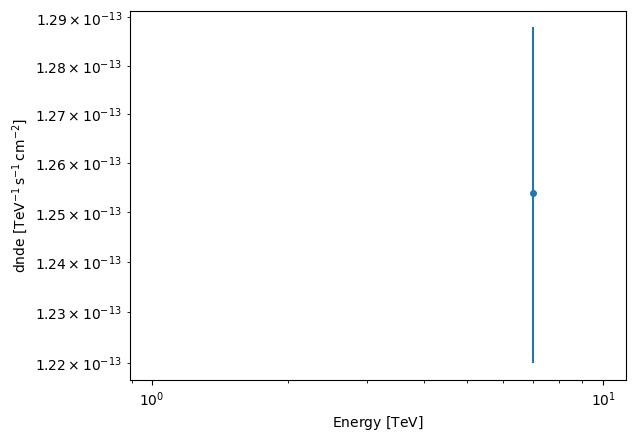

In [3]:
flux_points_3hwc = get_flux_points_3hwc(source_3hwc)
flux_points_3hwc.plot()

In [4]:
print("Flux-points metadata (3HWC):")
print(flux_points_3hwc.meta)

print("\nCatalog metadata (3HWC):")
print(catalog_3hwc.table.meta)

Flux-points metadata (3HWC):
{'source_name': '3HWC J1825-134', 'catalog_name': '3HWC', 'SED_TYPE': 'dnde', 'search_radius': <Quantity 0. deg>, 'spec0_radius': <Quantity 0. deg>, 'reference': 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract', 'sed_type_init': 'dnde'}

Catalog metadata (3HWC):
{'catalog_name': '3HWC', 'reference': 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract'}


In [5]:
flux_points_table_3hwc = create_flux_points_table_3hwc(source_3hwc)
flux_points_table_3hwc

e_ref,dnde,dnde_errn,dnde_errp,dnde_ul,is_ul
TeV,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),
float64,float64,float64,float64,float64,bool
7,1.25e-13,3.41e-15,3.39e-15,nan,False


## 2HWC catalog

The 2HWC catalog provides point-source and, for some sources, extended spectral models. The examples below show how to build tables and `FluxPoints` objects for both cases.

In [6]:
catalog_2hwc = SourceCatalog2HWC()
source_2hwc = catalog_2hwc["2HWC J1825-134"]

source_2hwc

### Point-source model

In [7]:
table_point_2hwc = create_flux_points_table_2hwc(source_2hwc)
table_point_2hwc

e_ref,dnde,dnde_err,dnde_ul,is_ul
TeV,1 / (TeV s cm2),1 / (TeV s cm2),,
float64,float64,float64,float64,bool
7.000,1.380e-13,8.166e-15,nan,False


<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='dnde [$\\mathrm{TeV^{-1}\\,s^{-1}\\,cm^{-2}}$]'>

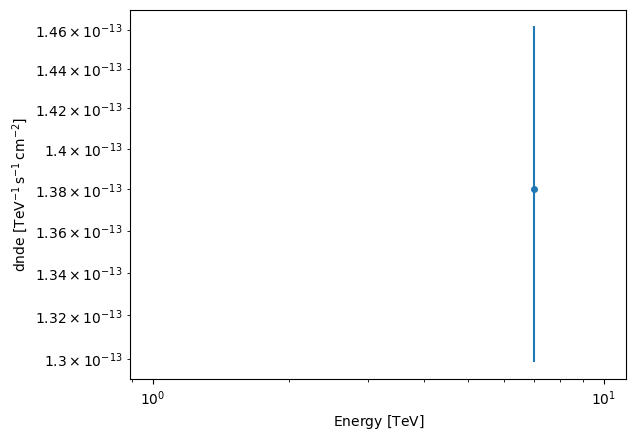

In [8]:
flux_points_point_2hwc = get_flux_points_2hwc(source_2hwc)
flux_points_point_2hwc.plot()

### Extended model

Some 2HWC sources do not provide an extended spectral model. In that case, FeuPy raises `ValueError`, which is handled explicitly below.

In [ ]:
try:
    table_extended_2hwc = create_flux_points_table_2hwc(
        source_2hwc,
        which="extended",
    )
    print(table_extended_2hwc)
except ValueError as error:
    print(f"Extended model unavailable: {error}")

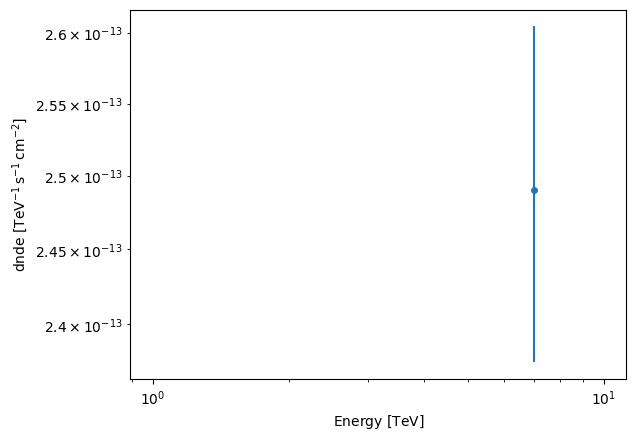

In [10]:
try:
    flux_points_extended_2hwc = get_flux_points_2hwc(
        source_2hwc,
        which="extended",
    )
    flux_points_extended_2hwc.plot()
except ValueError as error:
    print(f"Extended model unavailable: {error}")